##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


---

In [108]:
from matplotlib.colors import hsv_to_rgb
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def expand_mask(mask, box, img_h, img_w):
    ymin = int(box[0]*img_h); xmin = int(box[1]*img_w)
    ymax = int(box[2]*img_h); xmax = int(box[3]*img_w)
    mask_pil = Image.fromarray((mask*255).astype(np.uint8))
    mask_pil = mask_pil.resize((max(xmax-xmin,1), max(ymax-ymin,1)), Image.BILINEAR)
    canvas   = np.zeros((img_h, img_w), dtype=np.float32)
    canvas[ymin:ymax, xmin:xmax] = np.array(mask_pil) / 255.0
    return canvas > 0.5

def get_color(idx):
    return hsv_to_rgb([(idx * 0.618033988749895) % 1.0, 0.85, 0.95])

def visualize_single(img_array, boxes, classes, scores, masks, threshold):
    h, w    = img_array.shape[:2]
    overlay = img_array.copy().astype(np.float32)
    legend  = []

    for idx, (box, cls_id, score, mask) in enumerate(
            zip(boxes, classes.astype(int), scores, masks)):
        if score < threshold:
            continue

        label = mapping.get(cls_id, f"id:{cls_id}")
        color = get_color(idx)

       
        full_mask = expand_mask(mask, box, h, w)
        for c in range(3):
            overlay[:,:,c] = np.where(full_mask,
                overlay[:,:,c]*0.45 + color[c]*255*0.55, overlay[:,:,c])

        ymin=int(box[0]*h); xmin=int(box[1]*w)
        ymax=int(box[2]*h); xmax=int(box[3]*w)
        t = max(2, int(min(h,w)*0.003))
        overlay[ymin:ymin+t, xmin:xmax] = np.array(color)*255
        overlay[ymax-t:ymax, xmin:xmax] = np.array(color)*255
        overlay[ymin:ymax, xmin:xmin+t] = np.array(color)*255
        overlay[ymin:ymax, xmax-t:xmax] = np.array(color)*255

        legend.append(mpatches.Patch(color=color, label=f"{label}  {score:.2f}"))

    return overlay.astype(np.uint8), legend


In [109]:
import tensorflow as tf
import tensorflow_hub as hub

detector = hub.load("https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2/TensorFlow2/1024x1024/1")

In [110]:
import os
import tensorflow as tf
import numpy as np
from PIL import Image

input_path = 'test_images'

mapping = {1: 'person', 3: 'car', 17: 'cat', 52: 'banana', 84: 'book', 88: 'teddy bear'}

images = []
# get valid image files and ignore hidden Mac files like .DS_Store
valid_extensions = ('.jpg', '.jpeg', '.png')
image_files = [f for f in os.listdir(input_path) 
               if f.lower().endswith(valid_extensions) and not f.startswith('.')]

image_files = sorted(image_files)[:5]

for fname in image_files:
    image = Image.open(os.path.join(input_path, fname)).convert('RGB')
    img_array = np.array(image, dtype=np.float32)
    tensor = tf.convert_to_tensor(img_array, dtype=tf.uint8)
    resized = tf.image.resize_with_pad(tensor, target_height=1024, target_width=1024, method='bilinear')
    images.append(tf.cast(resized, tf.uint8))

processed_images = tf.stack(images)

In [111]:
processed_images.shape

TensorShape([5, 1024, 1024, 3])

In [112]:
processed_images[0].shape

TensorShape([1024, 1024, 3])

In [113]:
all_outputs = {
    "detection_boxes":   [],
    "detection_classes": [],
    "detection_scores":  [],
    "detection_masks":   [],
}

for i, img in enumerate(processed_images):
    single_batch = tf.expand_dims(img, axis=0)
    detector_output = detector(single_batch)

    all_outputs["detection_boxes"].append(detector_output["detection_boxes"].numpy()[0])
    all_outputs["detection_classes"].append(detector_output["detection_classes"].numpy()[0])
    all_outputs["detection_scores"].append(detector_output["detection_scores"].numpy()[0])
    all_outputs["detection_masks"].append(detector_output["detection_masks"].numpy()[0])


raw_boxes   = np.array(all_outputs["detection_boxes"])
raw_classes = np.array(all_outputs["detection_classes"])
raw_scores  = np.array(all_outputs["detection_scores"])
raw_masks   = np.array(all_outputs["detection_masks"])

print(f"\n✓ Done. boxes shape: {raw_boxes.shape}, masks shape: {raw_masks.shape}")


✓ Done. boxes shape: (5, 100, 4), masks shape: (5, 100, 33, 33)


In [114]:
image_files

['bears.jpg', 'bnanas.jpeg', 'btmm2.jpg', 'car.jpeg', 'cat.jpeg']

In [120]:
THRESHOLD   = 0.5

print(f"\n{'═'*65}")
print(f"  DETECTION RESULTS  (confidence threshold = {THRESHOLD})")
print(f"{'═'*65}")

for i, fname in enumerate(image_files):
    scores  = raw_scores[i]
    classes = raw_classes[i].astype(int)
    boxes   = raw_boxes[i]           # normalised [ymin, xmin, ymax, xmax]

    keep    = scores >= THRESHOLD
    scores_f  = scores[keep]
    classes_f = classes[keep]
    boxes_f   = boxes[keep]
    masks_f   = raw_masks[i][keep]   # shape [N_det, mask_H, mask_W]

    print(f"\n📷 Image {i+1}: {fname}  →  {keep.sum()} object(s) detected")
    print(f"  {'#':<4} {'Class':<18} {'Score':>6}   Bounding Box [ymin, xmin, ymax, xmax]")
    print(f"  {'-'*65}")
    for j, (cls_id, score, box) in enumerate(zip(classes_f, scores_f, boxes_f)):
        label = mapping.get(cls_id, f"id:{cls_id}")
        print(f"  {j:<4} {label:<18} {score:.3f}   "
              f"[{box[0]:.3f}, {box[1]:.3f}, {box[2]:.3f}, {box[3]:.3f}]")
    print(f"  Masks shape for this image: {masks_f.shape}   "
          f"(each mask is {raw_masks.shape[2]}×{raw_masks.shape[3]} px)")

print(f"\n{'═'*65}\n")


═════════════════════════════════════════════════════════════════
  DETECTION RESULTS  (confidence threshold = 0.5)
═════════════════════════════════════════════════════════════════

📷 Image 1: bears.jpg  →  8 object(s) detected
  #    Class               Score   Bounding Box [ymin, xmin, ymax, xmax]
  -----------------------------------------------------------------
  0    teddy bear         0.999   [0.384, 0.000, 0.794, 0.317]
  1    teddy bear         0.999   [0.490, 0.416, 0.845, 0.775]
  2    teddy bear         0.998   [0.268, 0.745, 0.651, 0.997]
  3    teddy bear         0.997   [0.180, 0.249, 0.560, 0.526]
  4    teddy bear         0.994   [0.357, 0.287, 0.716, 0.549]
  5    teddy bear         0.986   [0.341, 0.532, 0.659, 0.862]
  6    teddy bear         0.962   [0.180, 0.522, 0.466, 0.779]
  7    teddy bear         0.524   [0.242, 0.529, 0.534, 0.825]
  Masks shape for this image: (8, 33, 33)   (each mask is 33×33 px)

📷 Image 2: bnanas.jpeg  →  1 object(s) detected
  #    C

#### - The generated result used 0.5 confideince threshold

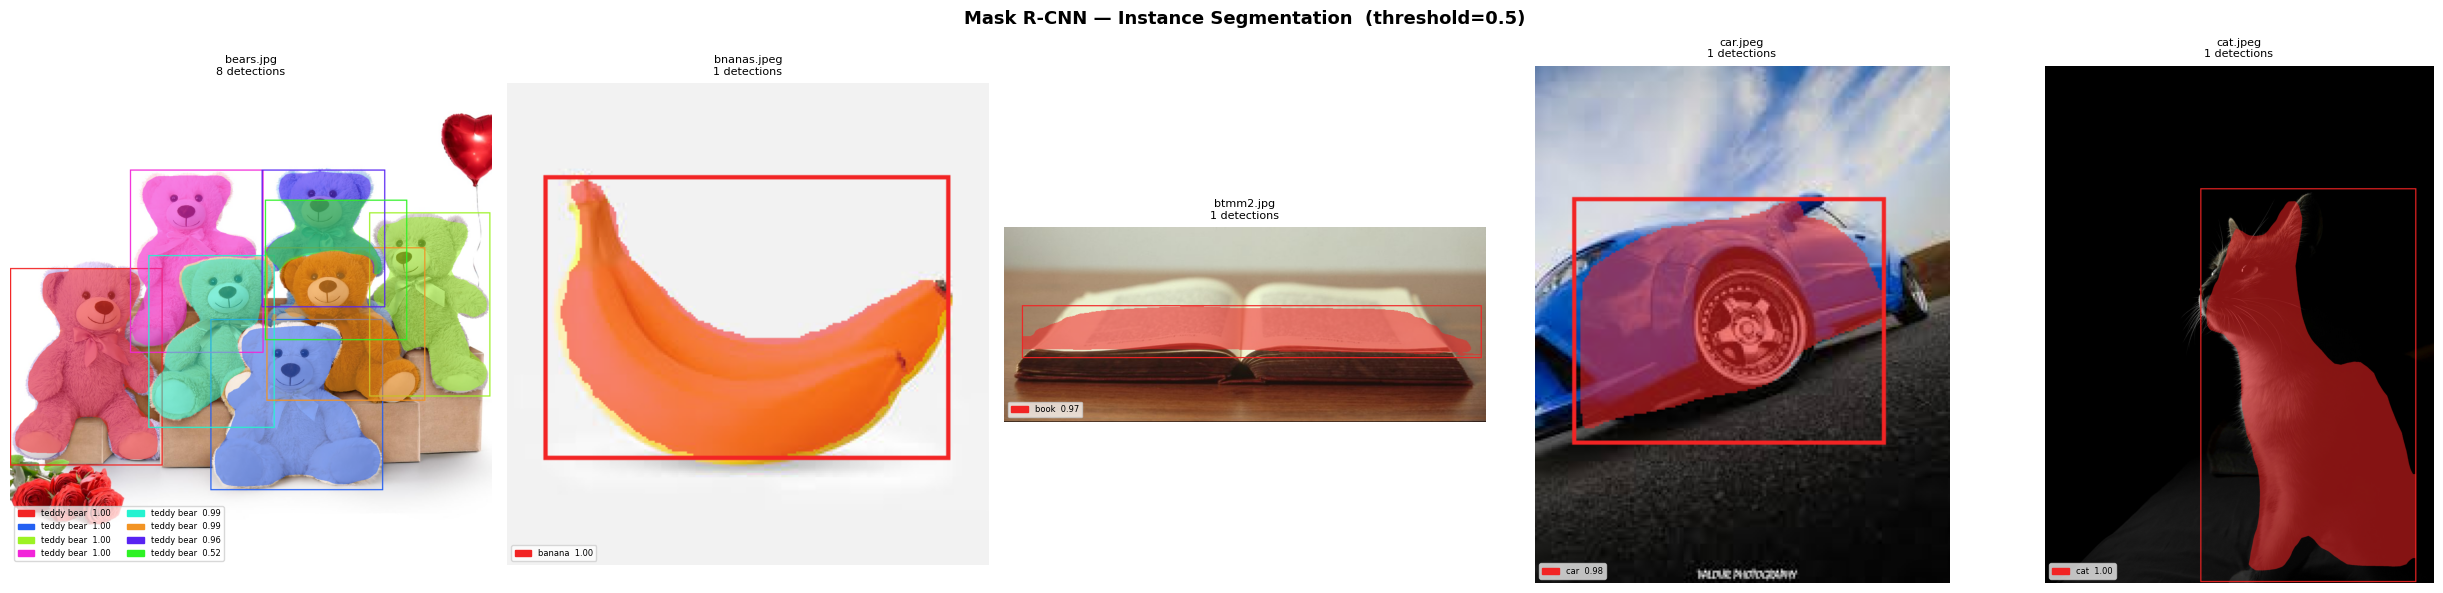

In [121]:
def show_gallery(threshold):
    fig, axes = plt.subplots(1, len(image_files), figsize=(5*len(image_files), 6))
    if len(image_files) == 1:
        axes = [axes]

    for i, (fname, ax) in enumerate(zip(image_files, axes)):
        img_array = np.array(Image.open(os.path.join(input_path, fname)).convert("RGB"))
        annotated, legend = visualize_single(
            img_array, raw_boxes[i], raw_classes[i],
            raw_scores[i], raw_masks[i], threshold
        )
        n = len(legend)
        ax.imshow(annotated)
        ax.set_title(f"{fname}\n{n} detections", fontsize=8)
        ax.axis("off")
        if legend:
            ax.legend(handles=legend, loc="lower left", fontsize=6,
                      framealpha=0.75, ncol=2)

    fig.suptitle(f"Mask R-CNN — Instance Segmentation  (threshold={threshold})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    
show_gallery(threshold=0.5)

In [122]:
THRESHOLD = 0.5

for i in range(len(processed_images)):
    scores = raw_scores[i]

    keep = scores >= THRESHOLD
    
    filtered_scores = scores[keep]
    
    print(f"Detected {len(filtered_scores)} objects with confidence > {THRESHOLD}")

Detected 8 objects with confidence > 0.5
Detected 1 objects with confidence > 0.5
Detected 1 objects with confidence > 0.5
Detected 1 objects with confidence > 0.5
Detected 1 objects with confidence > 0.5


####  0.3 threshold

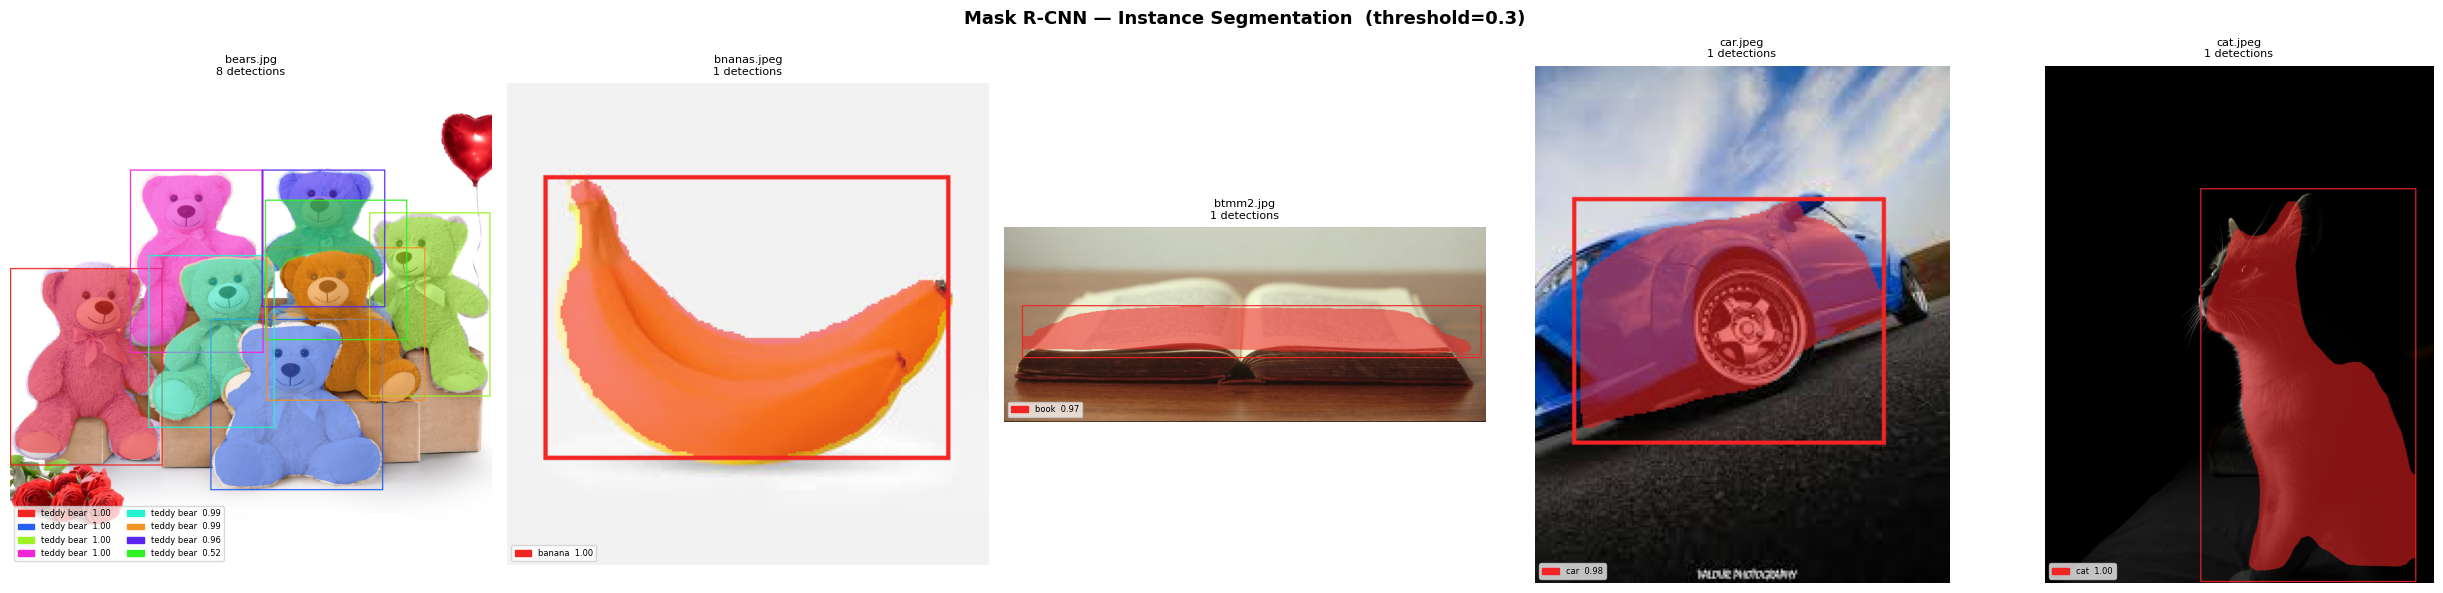

In [123]:
show_gallery(threshold=0.3)

In [124]:
THRESHOLD = 0.3 

for i in range(len(processed_images)):
    scores = raw_scores[i]

    keep = scores >= THRESHOLD
    
    filtered_scores = scores[keep]
    
    print(f"Detected {len(filtered_scores)} objects with confidence > {THRESHOLD}")

Detected 8 objects with confidence > 0.3
Detected 1 objects with confidence > 0.3
Detected 1 objects with confidence > 0.3
Detected 1 objects with confidence > 0.3
Detected 1 objects with confidence > 0.3


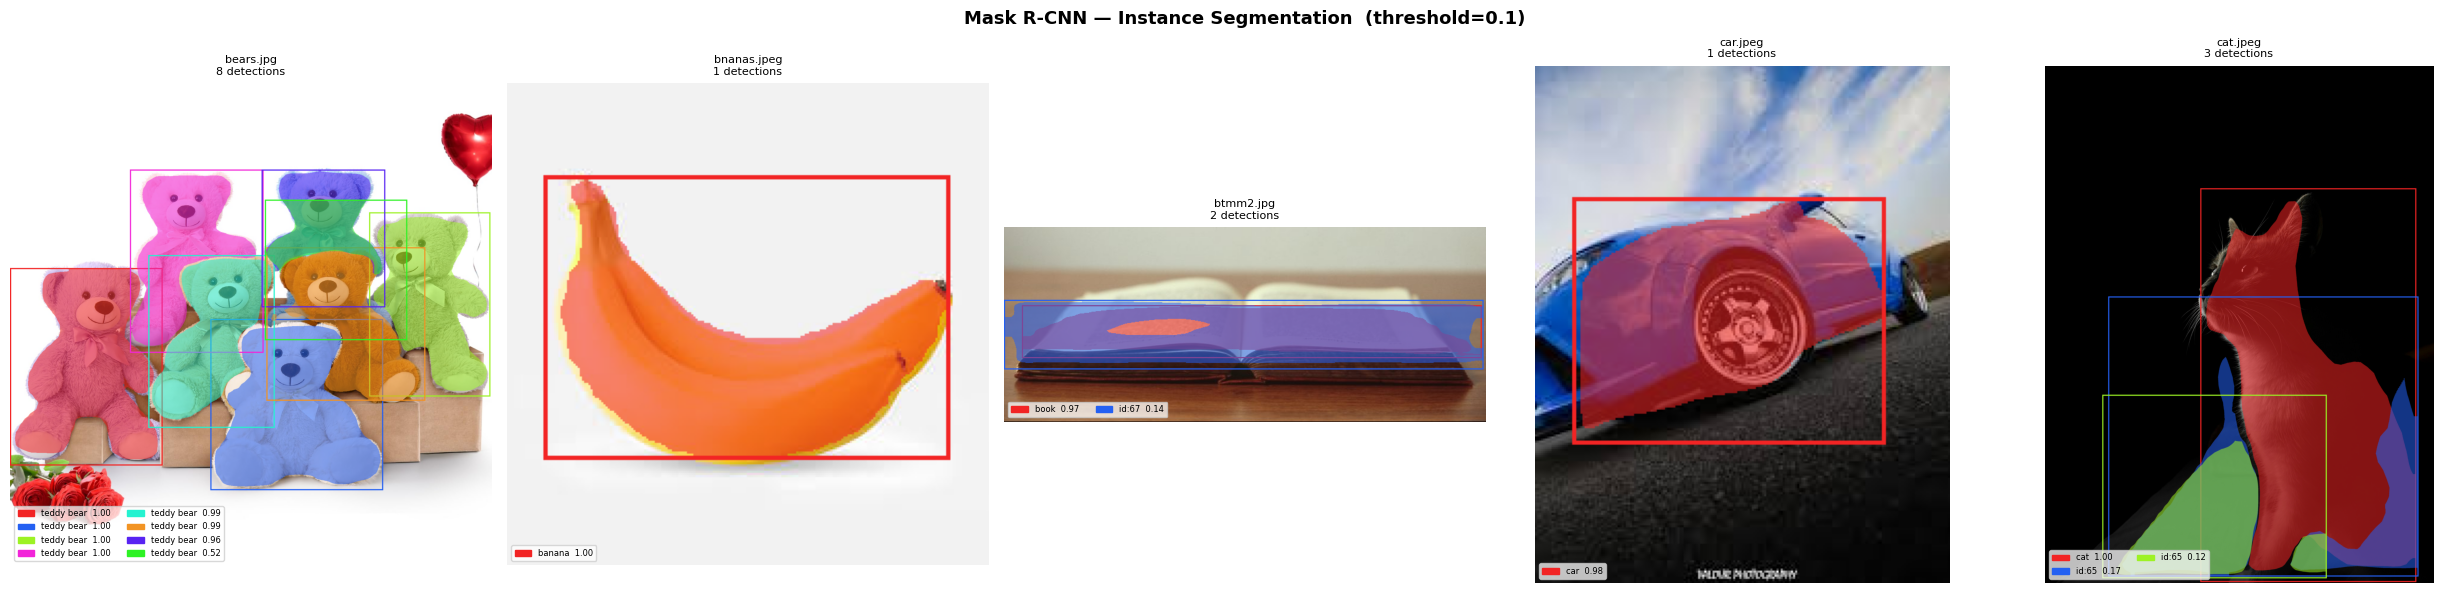

In [133]:
show_gallery(threshold=0.1)

In [134]:
THRESHOLD = 0.1 

for i in range(len(processed_images)):
    scores = raw_scores[i]

    keep = scores >= THRESHOLD
    
    filtered_scores = scores[keep]
    
    print(f"Detected {len(filtered_scores)} objects with confidence > {THRESHOLD}")

Detected 8 objects with confidence > 0.1
Detected 1 objects with confidence > 0.1
Detected 2 objects with confidence > 0.1
Detected 1 objects with confidence > 0.1
Detected 3 objects with confidence > 0.1


#### Observations:

The Mask R-CNN segmentation was tested on 5 images across three confidence thresholds (0.5, 0.3, and 0.1). At 0.5, only high-confidence detections were kept, providing clean results with minimal false positives. similary Lowering the threshold to 0.3, while 0.1 produced the most detections but introduced noticeable false positives. 

One limitation was observed in the banana image: the scene contained **2 bananas**, but the model only detected **1**. This is likely due to occlusion  reducing its confidence score below the threshold. .